# 8.1 Distinction Task: Sydney Housing Price Prediction
## Predicting House Prices Across Three Sydney Suburbs

This notebook builds a housing price prediction and decision support system for three Sydney suburbs with very different markets: **Bondi Beach** (premium coastal), **Epping** (middle-ring family) and **Liverpool** (affordable south-west). I collected 105 real sold properties (35 per suburb) from realestate.com.au and use them to build and compare three regression models, investigate where the models fail, and prepare a model for a simple web app.

**Sections**
1. Problem definition and data collection
2. Data understanding and feature engineering
3. Model development and evaluation
4. Investigating prediction failures
5. (Deployment is a separate Streamlit app, see app.py)

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 4)

## 1. Problem Definition and Data Collection

**The problem:** predict the sale price of a residential property from its characteristics. This is a **regression** problem (the target, sale price, is a continuous number)

**Why these three suburbs:** I chose three suburbs I would personally consider buying in, that represent very different markets:
- **Bondi Beach**: a premium eastern beachside suburb, mostly apartments, driven by lifestyle and location
  
- **Epping**: a middle-ring northern suburb popular with families, known for schools and a major train interchange, with a mix of houses and units

- **Liverpool**: an affordable, growing south-west suburb with more houses on larger blocks

These give a wide price range and different price drivers (beach vs schools/transport vs affordability/land), which makes the prediction problem more interesting

**Data collection:** I manually collected 105 sold listings (35 per suburb) from realestate.com.au, recording sale price, property type, bedrooms, bathrooms, car spaces, land size, sale date and address. Each row keeps its source URL for traceability

In [2]:
# Load the collected dataset
df = pd.read_csv('sydney_housing.csv')
print('Shape:', df.shape)
df.head()

Shape: (105, 11)


,suburb,property_type,bedrooms,bathrooms,car_spaces,land_size_sqm,year_built,sale_price,sale_date,address,url
0,Bondi Beach,House,4,3,0,178.0,1920.0,3620000,2026-09-12,"33 Wellington Street, Bondi Beach, NSW 2026",https://www.realestate.com.au/sold/property-ho...
1,Bondi Beach,Unit,1,1,0,1493.0,NaN,900000,2026-09-04,"55/34 Campbell Parade, Bondi Beach, NSW 2026",https://www.realestate.com.au/sold/property-ap...
2,Bondi Beach,Unit,2,2,1,593.0,1970.0,2125000,2026-08-17,"104/152 Campbell Parade, Bondi Beach, NSW 2026",https://www.realestate.com.au/sold/property-ap...
3,Bondi Beach,Unit,1,1,0,943.0,NaN,950000,2026-08-17,"21/40-42 Ramsgate Avenue, Bondi Beach, NSW 2026",https://www.realestate.com.au/sold/property-ap...
4,Bondi Beach,Unit,1,1,1,381.0,NaN,1075000,2026-08-14,"13/154 Glenayr Avenue, Bondi Beach, NSW 2026",https://www.realestate.com.au/sold/property-ap...


In [3]:
# Basic info and class/type balance
df.info()
print()
print('Properties per suburb:')
print(df['suburb'].value_counts())
print()
print('Property types:')
print(df['property_type'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   suburb         105 non-null    object 
 1   property_type  105 non-null    object 
 2   bedrooms       105 non-null    int64  
 3   bathrooms      105 non-null    int64  
 4   car_spaces     105 non-null    int64  
 5   land_size_sqm  101 non-null    float64
 6   year_built     14 non-null     float64
 7   sale_price     105 non-null    int64  
 8   sale_date      105 non-null    object 
 9   address        105 non-null    object 
 10  url            105 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 9.2+ KB

Properties per suburb:
suburb
Bondi Beach    35
Epping         35
Liverpool      35
Name: count, dtype: int64

Property types:
property_type
Unit     83
House    22
Name: count, dtype: int64


**Data quality, challenges and limitations**

A few important issues I found while collecting and checking the data:
- **Land size for units is misleading.** For apartments the website reports the size of the whole building block (sometimes several thousand sqm), not the individual apartment. So land size only means something for houses. I set land size to missing for units and let the model impute it, rather than feeding in a wrong value

- **The dataset is unit-heavy** (about 83 units vs 22 houses), because Bondi and Liverpool are apartment-dominated markets. This reflects reality but limits how well the model can learn house-specific pricing

- **Year built is mostly missing** (only ~14 of 105 listings show it), so I don't use it as a feature

- **Small sample and possible bias:** 105 properties is small, and the listings are only those that sold and published a price, withheld-price sales are excluded, which can bias the sample toward more marketable properties

These limitations mean the model should be treated as a rough decision-support tool, not a precise valuer

In [4]:
# Fix the unit land-size issue: null it for units (it's the block size, not the apartment)
df.loc[df['property_type'] == 'Unit', 'land_size_sqm'] = np.nan
print('Land size now missing for', df['land_size_sqm'].isna().sum(), 'rows (all units + a few houses)')

Land size now missing for 83 rows (all units + a few houses)


## 2. Data Understanding and Feature Engineering

I explore the price distribution, compare suburbs, and decide which features matter most

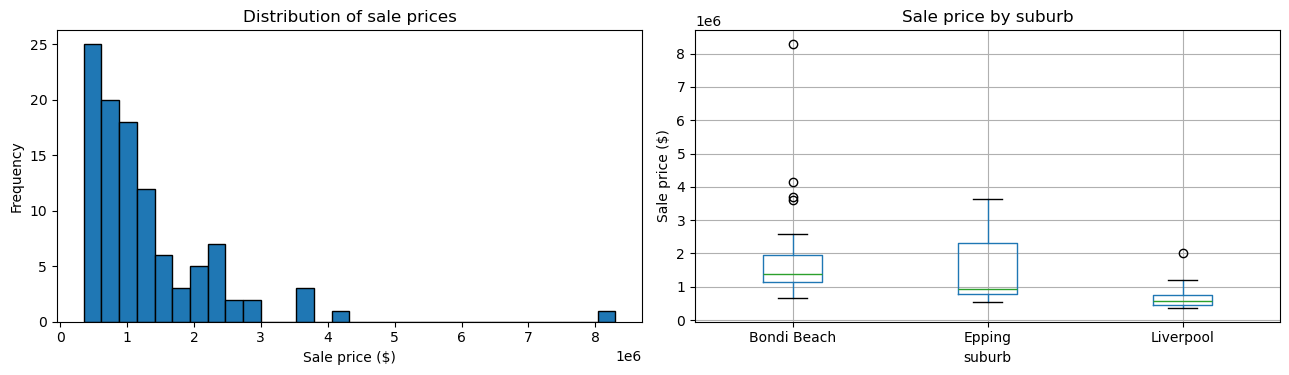

In [5]:
# Price distribution overall and by suburb
fig, axes = plt.subplots(1, 2, figsize = (13, 4))
df['sale_price'].plot(kind = 'hist', bins = 30, ax = axes[0], edgecolor = 'black')
axes[0].set_title('Distribution of sale prices')
axes[0].set_xlabel('Sale price ($)')

df.boxplot(column = 'sale_price', by = 'suburb', ax = axes[1])
axes[1].set_title('Sale price by suburb')
axes[1].set_ylabel('Sale price ($)')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [6]:
# Median price by suburb - the core comparison
print('Price summary by suburb:')
print(df.groupby('suburb')['sale_price'].agg(['min', 'median', 'max']).round(0))

Price summary by suburb:
                min     median      max
suburb                                 
Bondi Beach  665000  1370000.0  8300000
Epping       535000   928880.0  3638000
Liverpool    350000   570000.0  2000000


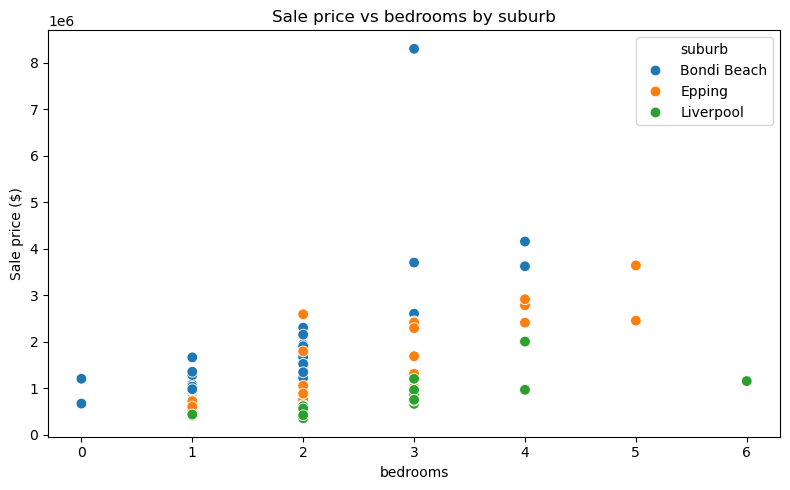

In [7]:
# Price vs bedrooms, coloured by suburb
plt.figure(figsize = (8, 5))
sns.scatterplot(data = df, x = 'bedrooms', y = 'sale_price', hue = 'suburb', s = 60)
plt.title('Sale price vs bedrooms by suburb')
plt.ylabel('Sale price ($)')
plt.tight_layout()
plt.show()

**Trends over time**

I also check whether prices moved over the collection period (the sales span several months of 2026)

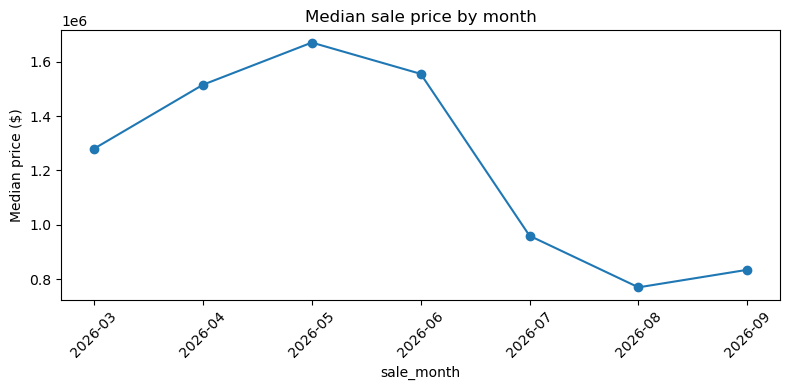

In [8]:
# Simple time trend
df['sale_month'] = pd.to_datetime(df['sale_date']).dt.to_period('M').astype(str)
monthly = df.groupby('sale_month')['sale_price'].median()
monthly.plot(marker = 'o')
plt.title('Median sale price by month')
plt.ylabel('Median price ($)')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

**Three features I expect to matter most (before modelling):**
1. **Suburb**: the three markets are priced very differently, so which suburb a property is in should be the single biggest driver
2. **Bedrooms**: more bedrooms generally means a bigger, more expensive property
3. **Property type**: houses usually cost more than units, especially in the same suburb

**Feature engineering decisions:** I keep the model features simple and honest given the small dataset: bedrooms, bathrooms, car spaces and land size (numeric), plus suburb and property type (categorical, one-hot encoded). I deliberately avoid inventing complex engineered features that could overfit 105 rows. I fixed the misleading unit land size (above), which is the most important data cleaning step. This matches my market intuition - location (suburb) and size (bedrooms, type) should dominate


## 3. Model Development and Evaluation

I build three regression models of different types and compare them with 5-fold cross-validation

**The three models and why I chose them:**
- **Linear Regression**: a simple, interpretable baseline that assumes price is a weighted sum of the features. I expect it to underfit, because housing prices are not linear (e.g. the Bondi beach premium is not just additive), but it gives a useful floor to compare against
- **Random Forest Regressor**: a bagging ensemble of trees. It captures nonlinear effects and interactions, handles the mixed categorical/numeric features, and is robust to outliers
- **Gradient Boosting Regressor**: a boosting ensemble that builds trees sequentially, each correcting the last. It is usually the strongest performer on small tabular datasets

**My prediction before training:** I expect **Gradient Boosting or Random Forest to perform best**, and **Linear Regression to come last**, because the price relationships are nonlinear

In [9]:
# Define features and preprocessing
feat_num = ['bedrooms', 'bathrooms', 'car_spaces', 'land_size_sqm']
feat_cat = ['suburb', 'property_type']
X = df[feat_num + feat_cat]
y = df['sale_price']

num_pipe = Pipeline([('impute', SimpleImputer(strategy = 'median')),
                     ('scale', StandardScaler())])
preprocess = ColumnTransformer([
    ('num', num_pipe, feat_num),
    ('cat', OneHotEncoder(handle_unknown = 'ignore'), feat_cat)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (84, 6) | Test: (21, 6)


In [10]:
# Train and cross-validate all three models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators = 200, random_state = 42),
    'Gradient Boosting': GradientBoostingRegressor(random_state = 42)
}

kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
results = {}

for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    cv = cross_val_score(pipe, X_train, y_train, cv = kf, scoring = 'r2')
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results[name] = pipe
    print(f'{name}')
    print(f'  CV R2  : {cv.mean():.3f} (+/- {cv.std():.3f})')
    print(f'  Test R2: {r2_score(y_test, pred):.3f}')
    print(f'  Test MAE : ${mean_absolute_error(y_test, pred):,.0f}')
    print(f'  Test RMSE: ${np.sqrt(mean_squared_error(y_test, pred)):,.0f}')
    print()

Linear Regression
  CV R2  : 0.394 (+/- 0.731)
  Test R2: 0.360
  Test MAE : $576,967
  Test RMSE: $1,397,426

Random Forest
  CV R2  : 0.503 (+/- 0.470)
  Test R2: 0.382
  Test MAE : $541,157
  Test RMSE: $1,373,414

Gradient Boosting
  CV R2  : 0.597 (+/- 0.217)
  Test R2: 0.433
  Test MAE : $548,349
  Test RMSE: $1,315,626



**Discussion**

As I predicted, **Gradient Boosting performed best** (test R2 = 0.433, RMSE = $1.32m), followed by Random Forest (R2 = 0.382), with **Linear Regression last** (R2 = 0.360). The ranking matches my expectation that nonlinear models would win, confirming that the price relationships are not purely linear, the ensembles can capture effects like the Bondi location premium that a straight line model cannot

The cross-validation results are the most revealing part. Gradient Boosting not only had the highest mean CV R2 (0.597) but also by far the **most stable** one (± 0.217), while Linear Regression was both lowest and wildly unstable (0.394 ± 0.731, the standard deviation is almost twice the mean). This large spread tells me the models struggle to generalise across folds, which is a sign of the small dataset and a few extreme prices making prediction hard, rather than a problem with the models themselves

On fit: Linear Regression is **underfitting**, it is too simple for a nonlinear problem, so it scores poorly on both training and test data. The ensembles fit the patterns better, but their modest test R2 shows they are limited by the small, noisy data, not by their own capacity. I recommend **Gradient Boosting** as the most appropriate model: it had the best and most stable cross-validation score and the lowest RMSE

## 4. Investigating Prediction Failures

I look at the five properties with the largest prediction errors from the best model (Gradient Boosting) to understand where and why it fails

In [11]:
# Use the best model (Gradient Boosting) to find the biggest errors
best = results['Gradient Boosting']
pred_test = best.predict(X_test)

errors = X_test.copy()
errors['actual'] = y_test.values
errors['predicted'] = pred_test
errors['abs_error'] = np.abs(errors['actual'] - errors['predicted'])
top5 = errors.sort_values('abs_error', ascending = False).head(5)
print('Five largest prediction errors:')
top5[['suburb','property_type','bedrooms','actual','predicted','abs_error']].round(0)

Five largest prediction errors:


,suburb,property_type,bedrooms,actual,predicted,abs_error
30,Bondi Beach,Unit,3,8300000,2660690.0,5639310.0
10,Bondi Beach,House,3,3700000,1998889.0,1701111.0
18,Bondi Beach,Unit,1,1660000,988714.0,671286.0
89,Liverpool,House,3,935000,1503161.0,568161.0
0,Bondi Beach,House,4,3620000,4125098.0,505098.0


In [12]:
# How much does the single $8.3m Bondi outlier hurt the model?
df_no_outlier = df[df['sale_price'] < 8000000]
Xo = df_no_outlier[feat_num + feat_cat]; yo = df_no_outlier['sale_price']
Xtr_o, Xte_o, ytr_o, yte_o = train_test_split(Xo, yo, test_size = 0.2, random_state = 42)
pipe_o = Pipeline([('prep', preprocess), ('model', GradientBoostingRegressor(random_state = 42))]).fit(Xtr_o, ytr_o)
pred_o = pipe_o.predict(Xte_o)
print('Gradient Boosting WITH outlier:    Test R2 = %.3f, MAE = $%s' % (r2_score(y_test, pred_test), 
                                                                        format(int(mean_absolute_error(y_test, pred_test)), ',')))
print('Gradient Boosting WITHOUT outlier: Test R2 = %.3f, MAE = $%s' % (r2_score(yte_o, pred_o), 
                                                                        format(int(mean_absolute_error(yte_o, pred_o)), ',')))

Gradient Boosting WITH outlier:    Test R2 = 0.433, MAE = $548,349
Gradient Boosting WITHOUT outlier: Test R2 = 0.707, MAE = $282,637


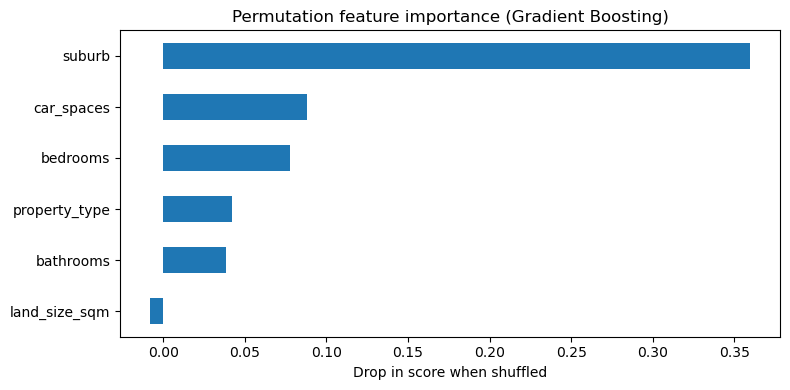

suburb           0.360
car_spaces       0.088
bedrooms         0.078
property_type    0.042
bathrooms        0.039
land_size_sqm   -0.008
dtype: float64


In [13]:
# Feature importance (permutation) - what the model relies on
r = permutation_importance(best, X_test, y_test, n_repeats = 10, random_state = 42)
imp = pd.Series(r.importances_mean, index = feat_num + feat_cat).sort_values()
imp.plot(kind = 'barh')
plt.title('Permutation feature importance (Gradient Boosting)')
plt.xlabel('Drop in score when shuffled')
plt.tight_layout()
plt.show()
print(imp.sort_values(ascending = False).round(3))

**Discussion**

The five largest errors were all high price or unusual properties, and four of the five are in Bondi Beach. The worst by far was the **8.3m Bondi apartment**, which the model predicted at only 2.26m, an error of over 5.6m. This single unit is more than four times the price of any other apartment in the dataset, so the model, having never seen anything like it, badly underpredicted it. The other big misses were a 3.7m Bondi house, a 1.66m Bondi unit and a 3.62m Bondi house, all premium properties whose price comes from qualities the data doesn't capture

To measure the outlier's impact I removed the 8.3m unit and retrained. The test R2 jumped from **0.433 to 0.707** and the MAE nearly halved, from **548,349 to 282,637**. This is strong evidence of how sensitive a small data model is to a single extreme value, one row out of 105 was dragging the whole model's accuracy down

The permutation feature importance confirms my Section 2 prediction: **suburb is by far the most important feature (0.36)**, more than four times any other. Car spaces (0.09) and bedrooms (0.08) matter moderately, while land size actually has a slightly negative importance (-0.01), because it is missing for all units and imputed, so it carries almost no real signal

**Limitations revealed:** the model has no data on the things that actually explain the outliers, ocean views, luxury renovations, beachfront position or heritage value. A standard 3-bedroom Bondi apartment and an $8.3m penthouse look almost identical to the model on paper. So predictions should be treated cautiously for luxury or unusual properties, and high-end apartments are inherently much harder to model than typical family homes. Collecting features like view, condition, floor level or a text description of the listing would likely improve this

## 5. Deployment

The prediction model is deployed as a simple **Streamlit web app** (`app.py`), which lets a user enter a property's details and get a predicted sale price. I save the trained Gradient Boosting pipeline below so the app can load it.

See the report for screenshots and run instructions. To run the app locally:
```
pip install streamlit scikit-learn pandas joblib
streamlit run app.py
```

In [14]:
# Save the best model pipeline for the web app
final_model = Pipeline([('prep', preprocess), ('model', GradientBoostingRegressor(random_state = 42))])
final_model.fit(X, y)   # fit on all data for deployment
joblib.dump(final_model, 'house_price_model.pkl')
print('Model saved as house_price_model.pkl')

Model saved as house_price_model.pkl
